# TArea 4

### 📦 Carga de librerías necesarias
Importamos las bibliotecas que utilizaremos a lo largo del análisis espacial.

In [ ]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

# Manipulación de datos
import numpy as np
import pandas as pd

# Datos espaciales vectoriales y raster
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.merge import merge
from rasterio.features import rasterize
import rioxarray as rxr
from rasterstats import zonal_stats

# Geometría y análisis espacial
from shapely.geometry import Point, Polygon
from shapely.ops import unary_union

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Análisis estadístico
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Web scraping y APIs
import requests
from bs4 import BeautifulSoup
import osmnx as ox

# Formato HDF (usado por MODIS)
from pyhdf.SD import SD, SDC

# Información del entorno
print("Estás trabajando en esta carpeta:")
print(os.getcwd())

Estás trabajando en esta carpeta:
c:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4


In [ ]:
#!pip install rioxarray

## 3.1 Descarga de áreas protegidas desde OpenStreetMap
- Consultamos la API de Overpass para obtener polígonos etiquetados como áreas protegidas dentro de Perú y filtramos por categorías relevantes (`protect_class` 2, 4, 6).

    - usando el Peru’s_protected-area_polygons_from_OSM.ipynb se creo *"areas_protegidas_solo_peru.gpkg"*

## 3.2 Download VCF (MOD44B v061) for 2024 (25 pts)

1. Register for an Earthdata Login (if you haven’t already).
2. Using requests or wget, programmatically pull all tiles covering Peru for collection 6.1, subset “Percent Tree Cover” (science dataset Percent_Tree_Cover), year = 2024.

- *Ejecutar --> python download_modis_lads.py*

3. Mosaic & reproject to EPSG:4326; name the raster vcf_2024_peru.tif.
Hint: rio merge, gdalwarp -t_srs EPSG:4326, or rioxarray.combine_by_coords.
4. It has many layers. We want to work with Percent_Tree_Cover.

## PAso 1: crear "*python convert_hdf_to_tif.py*"
- me permite convertir todos los hdf en tif individuales.

    ## Secuencia completa de comandos convertir hdf en tif
    1. Instalar GDAL
    conda install -c conda-forge gdal

    2. Verificar instalación
    python -c "from osgeo import gdal; print('GDAL instalado correctamente')"

    3. Ejecutar tu script
    python convert_hdf_to_tif.py

## PAso 2: crear "*Mosaico.ipynb*"
   - Se unifican los archivos `.tif` usando procesamiento por lotes para optimizar el uso de memoria, debido al gran tamaño total (291 archivos).
   - El mosaico final conserva la resolución original y valores de cobertura arbórea sin alteraciones.
   - Durante la creación del mosaico final, se intentó unir todos los archivos en una sola operación. Sin embargo, el proceso falló por un error de asignación de memoria (más de **46 GB** necesarios para combinar todos los píxeles). 
      Este problema se resolvio:
      - Dividiendo la combinación final en subgrupos más pequeños
      - Usando técnicas como `gdalbuildvrt` + `gdal_translate`
      - Ejecutando en un entorno con más memoria disponible

In [1]:
#!pip install seaborn

In [2]:
#!pip install scikit-learn

## Configuración de rutas y parámetros

In [ ]:
# Configuración de directorios
BASE_DIR = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4"
BATCH_PATTERN = os.path.join(BASE_DIR, "temp_batch_*.tif")
PROTECTED_AREAS_SHP = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\areas_protegidas_solo_peru.gpkg"  # ACTUALIZAR
OUTPUT_CSV = os.path.join(BASE_DIR, "buffer_statistics.csv")
OUTPUT_PIXEL_CSV = os.path.join(BASE_DIR, "pixel_level_rdd.csv")

# Parámetros de análisis
BUFFER_DISTANCES = [5000, 10000, 20000, 25000]  # metros (5, 10, 20, 25 km)
RDD_BUFFER_DISTANCE = 25000  # Solo 25km para RDD píxel-nivel

In [65]:
areas_protegidas_peru_unicas.to_file("areas_protegidas_solo_peru.gpkg", driver="GPKG")

In [3]:
#!pip install scipy

## Visualización de archivos .tif individuales

## PAso 2: crear mosaico
   - Se unifican los archivos `.tif` usando procesamiento por lotes para optimizar el uso de memoria, debido al gran tamaño total (291 archivos).
   - El mosaico final conserva la resolución original y valores de cobertura arbórea sin alteraciones.


### paso 2.1: "*Mosaico.ipynb*"
   - Durante la creación del mosaico final, se intentó unir todos los archivos en una sola operación. Sin embargo, el proceso falló por un error de asignación de memoria (más de **46 GB** necesarios para combinar todos los píxeles). 
      Este problema se resolvio:
      - Dividiendo la combinación final en subgrupos más pequeños
      - Usando técnicas como `gdalbuildvrt` + `gdal_translate`
      - Ejecutando en un entorno con más memoria disponible
   se crearon los archivos  temp_batch_* .tif
para visualizar mejor el problema: 
- V1: *temp_batch_22.tif* 

In [79]:
from scipy.stats import binned_statistic

c:\Users\usuario\anaconda3\envs\geo_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128506 (\N{WORLD MAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


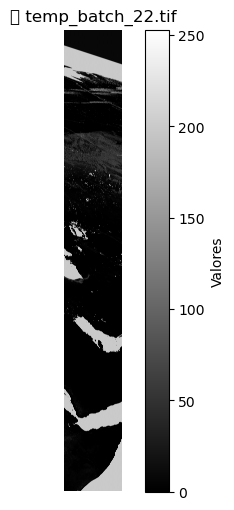

CRS: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Resolución: (231.65635826375006, 231.65635826374987)
Dimensiones: 4800 x 38400
Número de bandas: 1


In [2]:
import rasterio
import matplotlib.pyplot as plt
import os

def ver_tif_individual(nombre_archivo, carpeta):
    ruta_completa = os.path.join(carpeta, nombre_archivo)
    
    if not os.path.exists(ruta_completa):
        print(f"❌ El archivo '{nombre_archivo}' no se encontró en la ruta dada.")
        return
    
    with rasterio.open(ruta_completa) as src:
        plt.figure(figsize=(6, 6))
        plt.imshow(src.read(1), cmap='gray')  # Mostrar primera banda
        plt.title(f"🗺️ {nombre_archivo}")
        plt.colorbar(label="Valores")
        plt.axis('off')
        plt.show()
        
        # Información básica
        print(f"CRS: {src.crs}")
        print(f"Resolución: {src.res}")
        print(f"Dimensiones: {src.width} x {src.height}")
        print(f"Número de bandas: {src.count}")

# Define la ruta a la carpeta
carpeta = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4"

# Llama a la función con el archivo que quieres abrir
ver_tif_individual("temp_batch_22.tif", carpeta)


para visualizar mejor el problema: 
- V1: *mosaico_peru.tif* 

### PAso 2.2: *mosaico_peru.tif*
   - Luego me di cuenta que los nombre de los HDf tenian cordenadas asi que cree un .py que filtre los hdf descargados con las cordenadas 
   + Cree el vcf_2024_peru.py > que me retorna un mosaico  *mosaico_peru.tif* que filtra estas cordenadas h09, h10, h11, h12, v08, v09, v10, v11
   - ,pero como era muy grande y demoraba mucho en correr decidi crear otro cordenadas mas acotadas

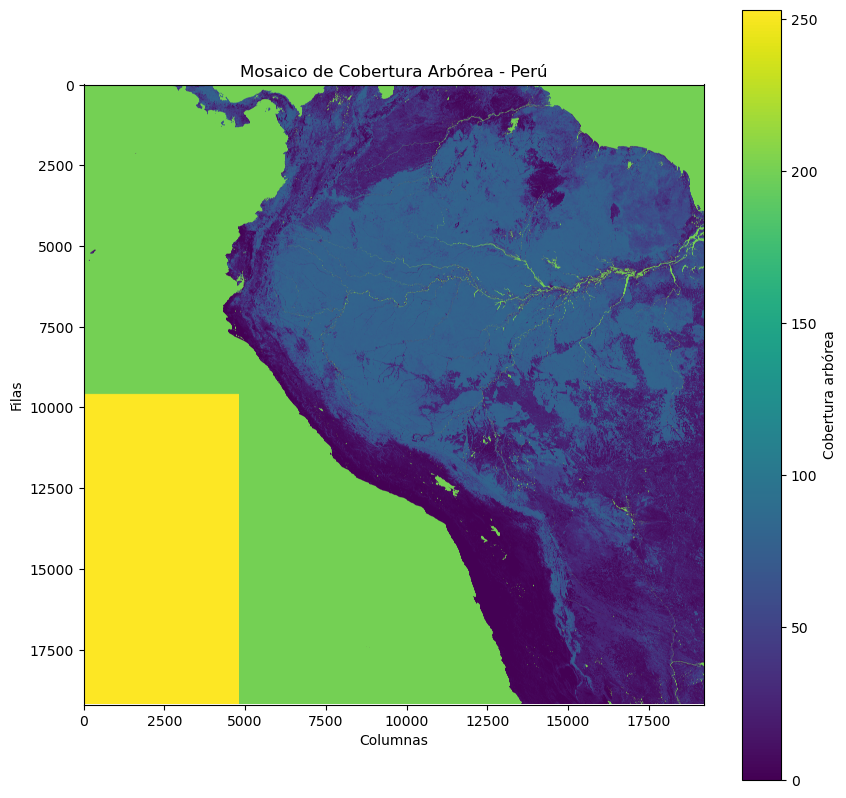

In [10]:
import rasterio
import matplotlib.pyplot as plt

# Ruta del mosaico
mosaic_path = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru.tif"

# Abrir el archivo raster
with rasterio.open(mosaic_path) as src:
    mosaic_data = src.read(1)  # Leer la primera banda

    # Mostrar la imagen
    plt.figure(figsize=(10, 10))
    plt.imshow(mosaic_data, cmap='viridis')
    plt.colorbar(label='Cobertura arbórea')
    plt.title("Mosaico de Cobertura Arbórea - Perú")
    plt.xlabel("Columnas")
    plt.ylabel("Filas")
    plt.show()


   + Cree un py que me retorna un mosaico  *mosaico_peru_centrado.tif* 
   + que filtra este rango: valid_h = {'09', '10'} valid_v = { '09', '10'}
   - *Sin embargo se comio parte de tumbes. Por ende lo descarté.*

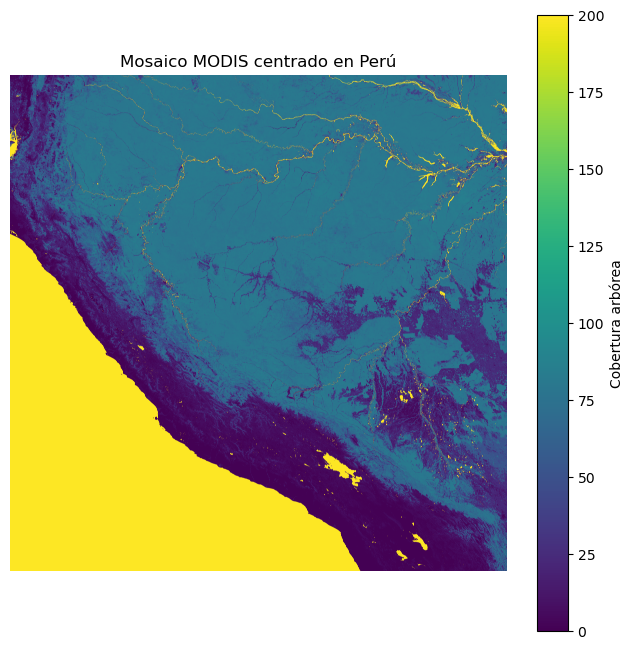

In [11]:
import rasterio
import matplotlib.pyplot as plt

# Ruta del nuevo mosaico centrado
mosaic_path = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_centrado.tif"

# Abrir el raster
with rasterio.open(mosaic_path) as src:
    data = src.read(1)

    # Mostrar la imagen
    plt.figure(figsize=(8, 8))
    plt.imshow(data, cmap='viridis')
    plt.title("Mosaico MODIS centrado en Perú")
    plt.colorbar(label="Cobertura arbórea")
    plt.axis("off")
    plt.show()


   + Cree el vcf_2024_peru_1.py > que me retorna un mosaico  *mosaico_peru_completo.tif* 
   + que filtra este rango: valid_h = {'08', '09', '10'} valid_v = { '09', '10','11'}
   - Este raster muestra al peru completo y no demora mucho en cargar

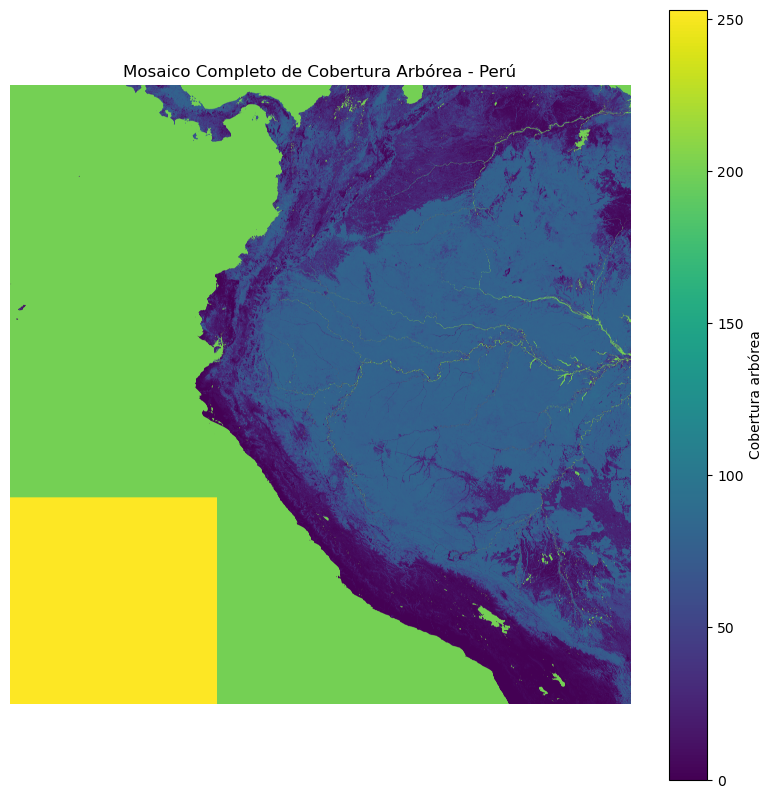

In [13]:
import rasterio
import matplotlib.pyplot as plt

# Ruta del mosaico completo
mosaic_path = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo.tif"

# Abrir y mostrar el mosaico
with rasterio.open(mosaic_path) as src:
    data = src.read(1)

    plt.figure(figsize=(10, 10))
    plt.imshow(data, cmap='viridis')
    plt.title("Mosaico Completo de Cobertura Arbórea - Perú")
    plt.colorbar(label="Cobertura arbórea")
    plt.axis('off')
    plt.show()

### Reproyección del raster
- Me fije que los raster estaban en sistema sinuidal asi que los tuve que reproyectar al CRS: EPSG:4326 con el siguinte codigo.
- Al reproyectarlo se guardo como **mosaico_peru_completo_4326.tif**

In [12]:
import rasterio

ruta_raster = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo.tif"

with rasterio.open(ruta_raster) as src:
    print("CRS original:", src.crs)


CRS original: PROJCS["unnamed",GEOGCS["Unknown datum based upon the custom spheroid",DATUM["Not specified (based on custom spheroid)",SPHEROID["Custom spheroid",6371007.181,0]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [13]:
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Rutas
ruta_raster = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo.tif"
ruta_salida = ruta_raster.replace(".tif", "_4326.tif")

with rasterio.open(ruta_raster) as src:
    dst_crs = "EPSG:4326"  # Sistema objetivo (WGS84)

    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds)

    kwargs = src.meta.copy()
    kwargs.update({
        "crs": dst_crs,
        "transform": transform,
        "width": width,
        "height": height
    })

    with rasterio.open(ruta_salida, "w", **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.nearest
            )

print("✅ Raster reproyectado guardado en:", ruta_salida)


✅ Raster reproyectado guardado en: C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo_4326.tif


### ✂️ Recorte del raster usando geometría de Perú
Recortamos el mosaico MODIS utilizando los límites de distritos para conservar solo los datos dentro del país.
- se guargo como **mosaico_peru_completo_4326_recortado_peru.tif**

In [14]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd

# Rutas
ruta_raster = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo_4326.tif"
ruta_distritos = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\shape_file\DISTRITOS.shp"
ruta_salida = ruta_raster.replace(".tif", "_recortado_peru.tif")

# Leer shapefile
gdf_distritos = gpd.read_file(ruta_distritos)

# Unión de todos los distritos para tener el contorno de todo Perú
peru_union = gdf_distritos.unary_union

# Abrir el raster
with rasterio.open(ruta_raster) as src:
    # Recortar usando la geometría de Perú (en EPSG:4326, debe coincidir con el raster)
    out_image, out_transform = mask(src, [peru_union], crop=True)
    
    # Actualizar metadatos para el nuevo raster recortado
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": out_image.shape[1],
        "width": out_image.shape[2],
        "transform": out_transform
    })
    
    # Guardar raster recortado
    with rasterio.open(ruta_salida, "w", **out_meta) as dest:
        dest.write(out_image)

print("✅ Raster recortado guardado en:", ruta_salida)


C:\Users\usuario\AppData\Local\Temp\ipykernel_6780\1567282396.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  peru_union = gdf_distritos.unary_union


✅ Raster recortado guardado en: C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo_4326_recortado_peru.tif


### 🖼️ Visualización del raster recortado
Verificamos visualmente el resultado del recorte espacial aplicado al mosaico MODIS.

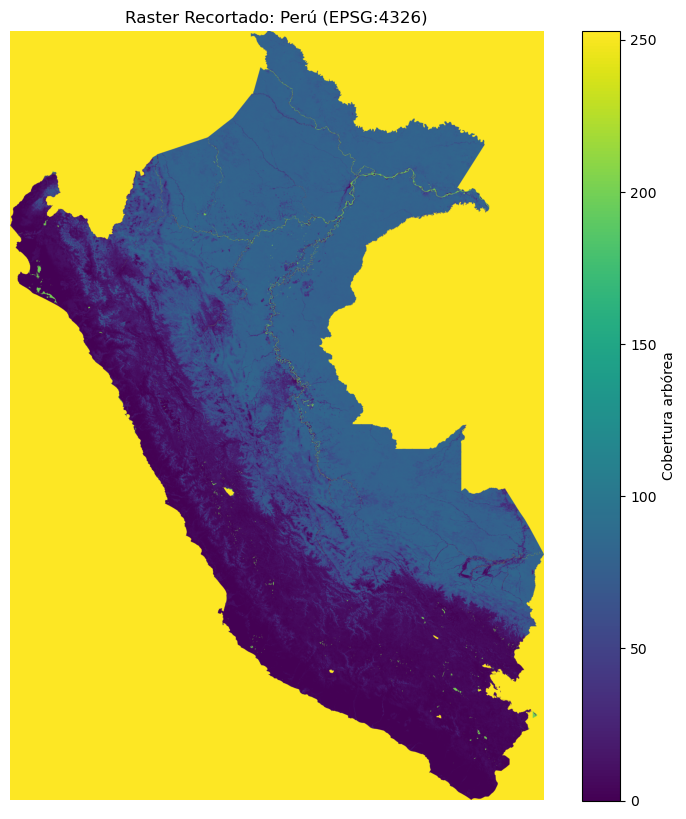

CRS: EPSG:4326
Extensión: BoundingBox(left=-81.32841038707015, bottom=-18.35126901535135, right=-68.6505259497974, top=-0.03832490233181396)


In [16]:
import rasterio
import matplotlib.pyplot as plt

# Ruta al raster recortado
ruta_raster = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo_4326_recortado_peru.tif"

# Abrir el raster
with rasterio.open(ruta_raster) as src:
    raster_data = src.read(1)  # Leer la primera banda
    crs = src.crs
    bounds = src.bounds

# Visualizar
plt.figure(figsize=(10, 10))
plt.imshow(raster_data, cmap='viridis')
plt.title("Raster Recortado: Perú (EPSG:4326)")
plt.colorbar(label='Cobertura arbórea')
plt.axis('off')
plt.show()

# Información básica
print("CRS:", crs)
print("Extensión:", bounds)


### 🗺️ Mapa de áreas protegidas sobre distritos
Superponemos las áreas protegidas sobre el shapefile de distritos para contextualizar su ubicación.

C:\Users\usuario\AppData\Local\Temp\ipykernel_5408\26996669.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_areas_unido = gpd.GeoDataFrame(geometry=[gdf_areas.unary_union], crs=gdf_areas.crs)


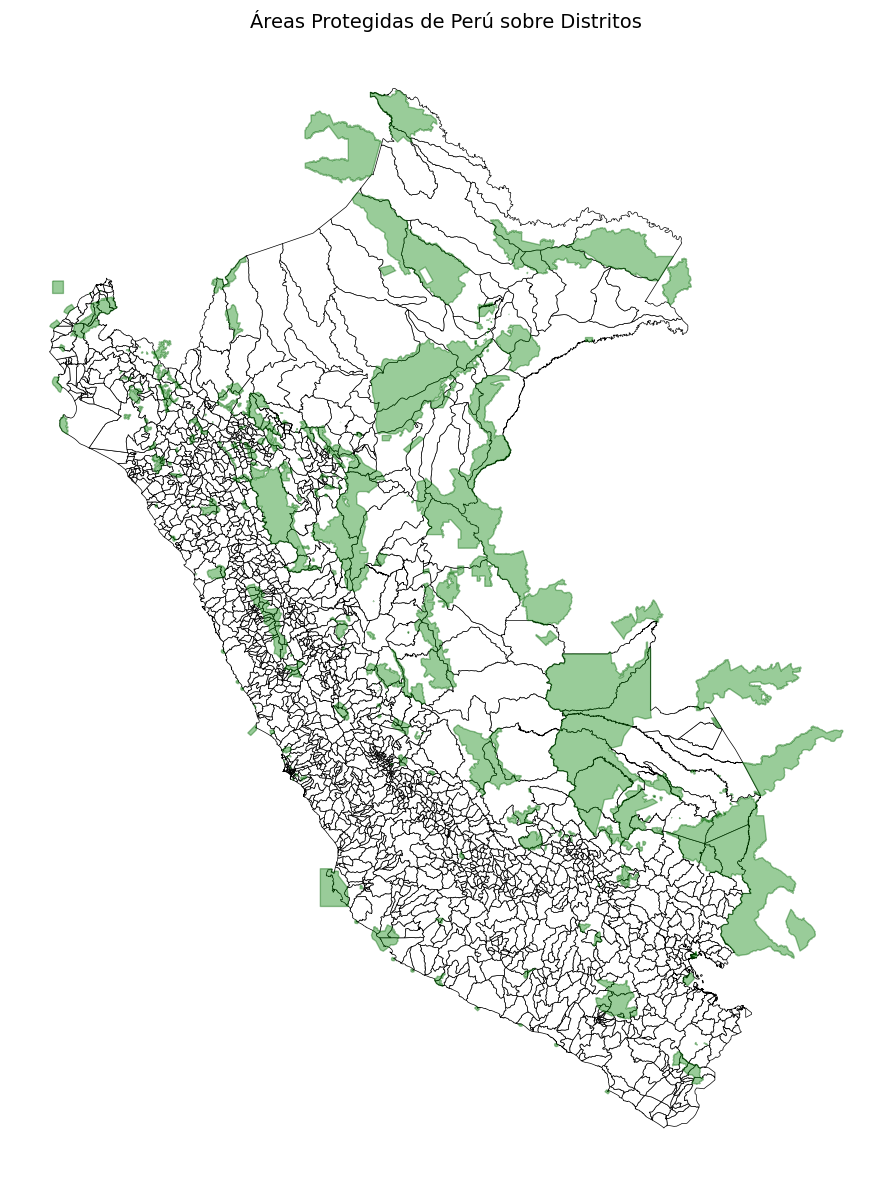

In [16]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 🔹 Rutas a los archivos
ruta_distritos = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\shape_file\DISTRITOS.shp"
ruta_areas = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\areas_protegidas_solo_peru.gpkg"

# 📌 Leer los shapefiles
gdf_distritos = gpd.read_file(ruta_distritos)
gdf_areas = gpd.read_file(ruta_areas)

# ✅ Unir todas las áreas protegidas en un solo polígono
gdf_areas_unido = gpd.GeoDataFrame(geometry=[gdf_areas.unary_union], crs=gdf_areas.crs)

# 🔄 Asegurarse de que ambas capas tengan el mismo sistema de referencia (CRS)
if gdf_distritos.crs != gdf_areas_unido.crs:
    gdf_areas_unido = gdf_areas_unido.to_crs(gdf_distritos.crs)

# 📊 Visualizar mapa
fig, ax = plt.subplots(figsize=(12, 12))

# Dibujar distritos como fondo
gdf_distritos.plot(ax=ax, color='white', edgecolor='black', linewidth=0.5)

# Dibujar áreas protegidas como sombreado transparente
gdf_areas_unido.plot(ax=ax, color='green', alpha=0.4, edgecolor='darkgreen', linewidth=1)

# Estética
ax.set_title("Áreas Protegidas de Perú sobre Distritos", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


### 🗺️ Áreas protegidas sobre raster de cobertura arbórea
Mostramos las áreas protegidas delimitadas sobre el mapa rasterizado del mosaico MODIS.

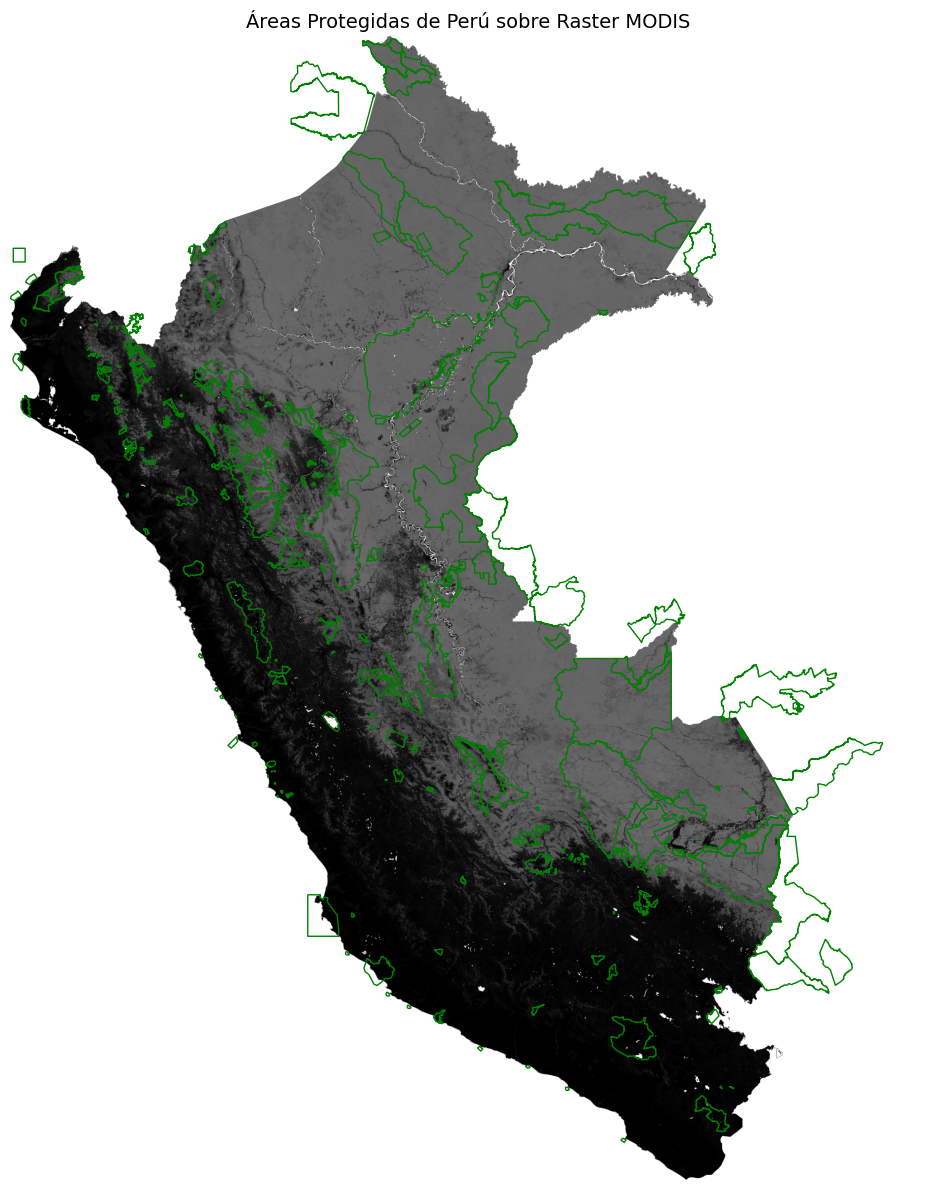

In [17]:
import geopandas as gpd
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# 📌 Rutas a los archivos
ruta_raster = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo_4326_recortado_peru.tif"
ruta_areas = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\areas_protegidas_solo_peru.gpkg"

# ✅ Leer el raster
src = rasterio.open(ruta_raster)

# ✅ Leer áreas protegidas
gdf_areas = gpd.read_file(ruta_areas)

# 🔄 Asegurar mismo CRS
if gdf_areas.crs != src.crs:
    gdf_areas = gdf_areas.to_crs(src.crs)

# ✅ Crear mapa
fig, ax = plt.subplots(figsize=(12, 12))

# Mostrar el raster
show(src, ax=ax, cmap='gray')  # Puedes cambiar a cmap='viridis', 'YlGn', etc.

# Mostrar áreas protegidas encima
gdf_areas.boundary.plot(ax=ax, color='green', linewidth=1)  # o fill con alpha

# Estética
ax.set_title("Áreas Protegidas de Perú sobre Raster MODIS", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


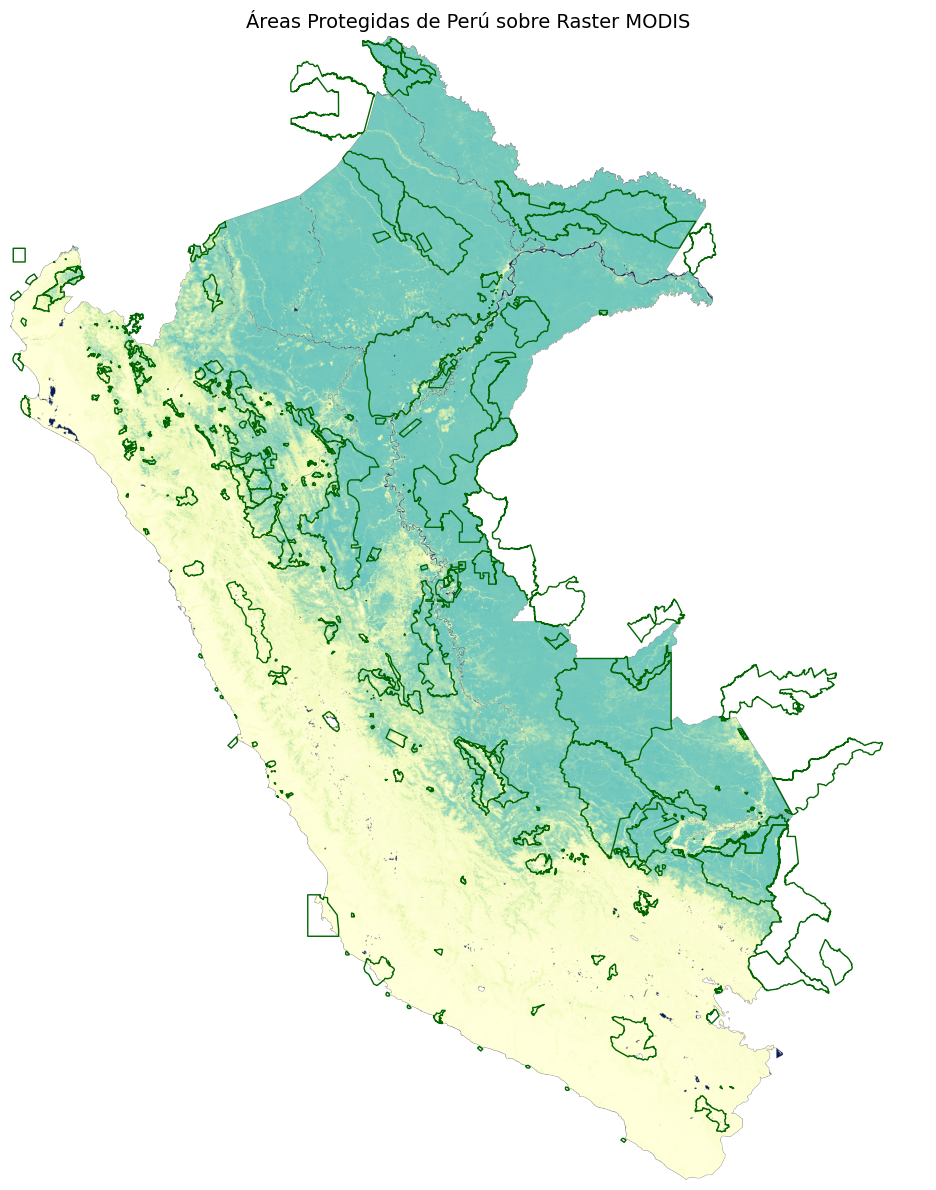

In [18]:
import geopandas as gpd 
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# 📌 Rutas a los archivos
ruta_raster = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo_4326_recortado_peru.tif"
ruta_areas = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\areas_protegidas_solo_peru.gpkg"

# ✅ Leer el raster
src = rasterio.open(ruta_raster)

# ✅ Leer áreas protegidas
gdf_areas = gpd.read_file(ruta_areas)

# 🔄 Asegurar mismo CRS
if gdf_areas.crs != src.crs:
    gdf_areas = gdf_areas.to_crs(src.crs)

# ✅ Crear mapa
fig, ax = plt.subplots(figsize=(12, 12))

# 🎨 Mostrar el raster con paleta agradable
show(src, ax=ax, cmap='YlGnBu')  # Opciones: 'viridis', 'terrain', 'gist_earth'

# 🟩 Dibujar solo el contorno de las áreas protegidas (sin relleno)
gdf_areas.boundary.plot(ax=ax, edgecolor='darkgreen', linewidth=1)

# Estética
ax.set_title("Áreas Protegidas de Perú sobre Raster MODIS", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()


### 💾 Exportación de estadísticas a CSV
Guardamos los resultados de las zonas de buffer en un archivo CSV en formato limpio.

In [28]:
import geopandas as gpd
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import zonal_stats
import pandas as pd
import os

# 📁 Rutas
ruta_areas = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\areas_protegidas_solo_peru.gpkg"
ruta_raster_original = r"C:\Users\usuario\Documents\GitHub\Spatial_Analysis_of_Peru-s_Protected_Areas\241878_hw4\modis_data\tifs\mosaico_peru_completo_4326_recortado_peru.tif"
ruta_raster_32718 = ruta_raster_original.replace(".tif", "_32718.tif")

# 🎯 Proyección objetivo (UTM zona 18 Sur)
epsg_utm = 32718
dst_crs = f"EPSG:{epsg_utm}"

# 📌 Reproyectar raster si es necesario
if not os.path.exists(ruta_raster_32718):
    with rasterio.open(ruta_raster_original) as src:
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)

        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        with rasterio.open(ruta_raster_32718, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.nearest)
    print("✅ Raster reproyectado a EPSG:32718.")
else:
    print("ℹ️ Raster ya reproyectado disponible.")

# ✅ Leer raster reproyectado y áreas
src = rasterio.open(ruta_raster_32718)
gdf_areas = gpd.read_file(ruta_areas).to_crs(epsg=epsg_utm)

# 📏 Distancias de buffer (en kilómetros)
buffers_km = [5, 10, 20, 25]

# 📦 Resultados
resultados = []

# Obtener campo de ID, si no hay, crear índice
if "ID" in gdf_areas.columns:
    id_field = "ID"
elif "park_id" in gdf_areas.columns:
    id_field = "park_id"
else:
    id_field = None

# 🔁 Procesar cada polígono
for idx, row in gdf_areas.iterrows():
    geom = row.geometry
    park_id = row[id_field] if id_field else idx

    for b in buffers_km:
        dist_m = b * 1000  # km → metros

        # Outer ring = buffer externo menos el polígono original
        outer_ring = geom.buffer(dist_m).difference(geom)

        # Inner ring = polígono original menos el buffer hacia adentro
        inner_ring = None if geom.buffer(-dist_m).is_empty else geom.difference(geom.buffer(-dist_m))

        # 📊 Outer buffer stats
        if not outer_ring.is_empty:
            outer_stats = zonal_stats(outer_ring, ruta_raster_32718, stats=["mean", "median", "std", "count"], nodata=0)
            resultados.append({
                "park_id": park_id,
                "buffer_km": b,
                "in_out": "outer",
                "mean_tc": outer_stats[0]["mean"],
                "median_tc": outer_stats[0]["median"],
                "sd_tc": outer_stats[0]["std"],
                "n_pixels": outer_stats[0]["count"],
                "Percent_Tree_Cover": outer_stats[0]["mean"]  # suposición: mean es % cobertura forestal
            })

        # 📊 Inner buffer stats
        if inner_ring and not inner_ring.is_empty:
            inner_stats = zonal_stats(inner_ring, ruta_raster_32718, stats=["mean", "median", "std", "count"], nodata=0)
            resultados.append({
                "park_id": park_id,
                "buffer_km": b,
                "in_out": "inner",
                "mean_tc": inner_stats[0]["mean"],
                "median_tc": inner_stats[0]["median"],
                "sd_tc": inner_stats[0]["std"],
                "n_pixels": inner_stats[0]["count"],
                "Percent_Tree_Cover": inner_stats[0]["mean"]
            })

# 📄 Convertir a DataFrame
df_resultados = pd.DataFrame(resultados)

# Guardar CSV con nuevo nombre
csv_salida = "estadisticas_buffers_forest_cover.csv"
df_resultados.to_csv(csv_salida, index=False)

print(f"✅ Resultados guardados en {csv_salida}")
print(df_resultados.head())


ℹ️ Raster ya reproyectado disponible.
✅ Resultados guardados en estadisticas_buffers_forest_cover.csv
   park_id  buffer_km in_out     mean_tc  median_tc       sd_tc  n_pixels  \
0        0          5  outer  115.986098        7.0  123.546795      2086   
1        0         10  outer  116.620489       11.0  122.593184      7399   
2        0         20  outer  117.049926       13.0  121.856077     27120   
3        0         25  outer  120.361968       19.0  121.427418     41512   
4        1          5  outer    2.876140        2.0    2.131115      1316   

   Percent_Tree_Cover  
0          115.986098  
1          116.620489  
2          117.049926  
3          120.361968  
4            2.876140  


In [4]:
#!pip install statsmodels

### 📈 3.4 Modelo de regresión discontinua (RDD)
Creamos una variable binaria D que indica si el píxel está dentro del área protegida, y aplicamos una regresión ponderada por cantidad de píxeles.


In [38]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# 1) Leer datos
ruta_csv = "estadisticas_buffers_forest_cover.csv"
df = pd.read_csv(ruta_csv)

# 2) Variable D: 1 si inner, 0 si outer
df['D'] = (df['in_out'] == 'inner').astype(int)

# 3) Definir X, y y los pesos
X = df[['D']].values                        # Variable independiente
y = df['Percent_Tree_Cover'].values        # Variable dependiente
weights = df['n_pixels'].values            # Pesos

# 4) Ajustar modelo de regresión ponderado
model = LinearRegression()
model.fit(X, y, sample_weight=weights)

# 5) Mostrar coeficientes
intercepto = model.intercept_
coef_D = model.coef_[0]

print("Coeficientes:")
print(f"Intercepto (outer): {intercepto:.4f}")
print(f"Efecto de estar en zona inner (D): {coef_D:.4f}")

Coeficientes:
Intercepto (outer): 86.6595
Efecto de estar en zona inner (D): 36.0358


### 📊 Visualización de resultados del modelo RDD
Representamos gráficamente las diferencias de cobertura arbórea promedio entre zonas internas y externas.


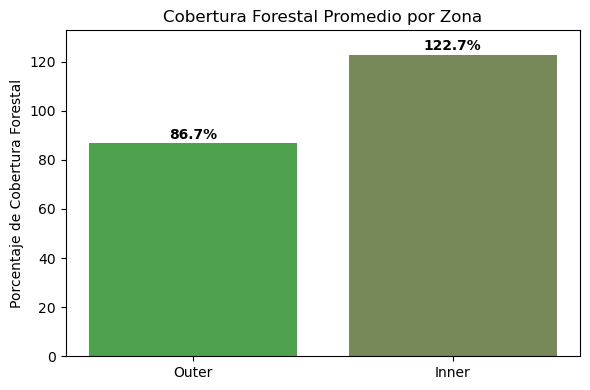

In [39]:
import matplotlib.pyplot as plt

# Valores ajustados
intercepto = 86.6595         # Outer
efecto_inner = 36.0358       # Diferencia de inner

# Valores predichos por el modelo
outer_pred = intercepto
inner_pred = intercepto + efecto_inner

# Crear gráfico de barras
zonas = ['Outer', 'Inner']
valores = [outer_pred, inner_pred]

plt.figure(figsize=(6, 4))
plt.bar(zonas, valores, color=['forestgreen', 'darkolivegreen'], alpha=0.8)
plt.title('Cobertura Forestal Promedio por Zona')
plt.ylabel('Porcentaje de Cobertura Forestal')
plt.ylim(0, max(valores) + 10)

# Mostrar valores sobre las barras
for i, v in enumerate(valores):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
